tables used:

processed - products, customers, geoloc, sellers

agg - orders_delivery_details, order_cost_detils, order_payments, order_review_summary

In [ ]:
import pandas as pd
import duckdb
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.ticker as mticker

sns.set_theme(style='whitegrid',
              palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

conn = duckdb.connect('../database/olist.db')

In [5]:
# let's check the order delivery details
query = """
    SELECT * from information_schema.tables
"""

conn.execute(query).df().head()


,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action,TABLE_COMMENT
0,olist,main,customers,BASE TABLE,None,None,None,None,None,YES,NO,None,None
1,olist,main,geoloc,BASE TABLE,None,None,None,None,None,YES,NO,None,None
2,olist,main,orders,BASE TABLE,None,None,None,None,None,YES,NO,None,None
3,olist,main,orders_delivery_details,BASE TABLE,None,None,None,None,None,YES,NO,None,None
4,olist,main,order_cost_details,BASE TABLE,None,None,None,None,None,YES,NO,None,None


# Overview

Total unique orders

In [ ]:
# Total Unique orders
query = """
    SELECT COUNT(distinct order_id) as 'Total Orders'
    FROM orders_delivery_details
"""

conn.execute(query).df()


,Total Orders
0,99441


Total revenue - 16.01M

In [20]:

query = """
    SELECT round(sum(opa.total_payment_value),2) as revenue
    FROM orders_delivery_details odd
    LEFT JOIN order_payments_agg opa
    on odd.order_id = opa.order_id
"""

conn.execute(query).df()


,revenue
0,16008872.12


Average, median review scores

In [25]:

query = """
    SELECT round(avg(ors.avg_score),2) as avg_score, round(median(ors.avg_score),2) as median_score
    FROM orders_delivery_details odd
    LEFT JOIN order_review_summary ors
    on odd.order_id = ors.order_id
"""

conn.execute(query).df()


,avg_score,median_score
0,4.09,5.0


Average, median order value

In [26]:

query = """
    SELECT round(avg(ocd.order_cost),2) as avg_value, round(median(ocd.order_cost),2) as median_value
    FROM orders_delivery_details odd
    LEFT JOIN order_cost_details ocd
    on odd.order_id = ocd.order_id
"""

conn.execute(query).df()


,avg_value,median_value
0,160.01,105.17


On-time vs Late deliveries

In [51]:

query = """
    with on_time_calc as (
        SELECT
            *,
            CASE
                WHEN delivery_days_accuracy <=0 then 1
                else 0
            END as 'on_time'
        FROM orders_delivery_details
    )
    select 
        round(avg(on_time), 2) as timely_per,
    from on_time_calc


"""

conn.execute(query).df().head()


,timely_per
0,0.9


Average, median delivery time

In [56]:

query = """
    SELECT
        round(avg(days_till_delivered),2) as avg_delivery_time,
        round(median(days_till_delivered),2) as median_delivery_time,
        round(mode(days_till_delivered),2) as median_delivery_time,
    FROM orders_delivery_details


"""

conn.execute(query).df().head()


,avg_delivery_time,median_delivery_time,median_delivery_time_1
0,12.5,10.0,7


Sellers

In [57]:

query = """
    SELECT
        count(distinct seller_id) as total_sellers
    FROM seller_performance


"""

conn.execute(query).df().head()


,total_sellers
0,3095


Order reviews

In [62]:

query = """
    SELECT
        sum(total_reviews_count) as total_reviews,
        sum(textual_reviews) as total_text_based,
        round(avg(avg_score),2) as avg_score
    FROM order_review_summary


"""

conn.execute(query).df().head()


,total_reviews,total_text_based,avg_score
0,99224.0,40977.0,4.09


# Analysis

C:\Users\Tejali\AppData\Local\Temp\ipykernel_21348\4102765112.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample(


Text(0.5, 1.0, 'Monthly revenue trend')

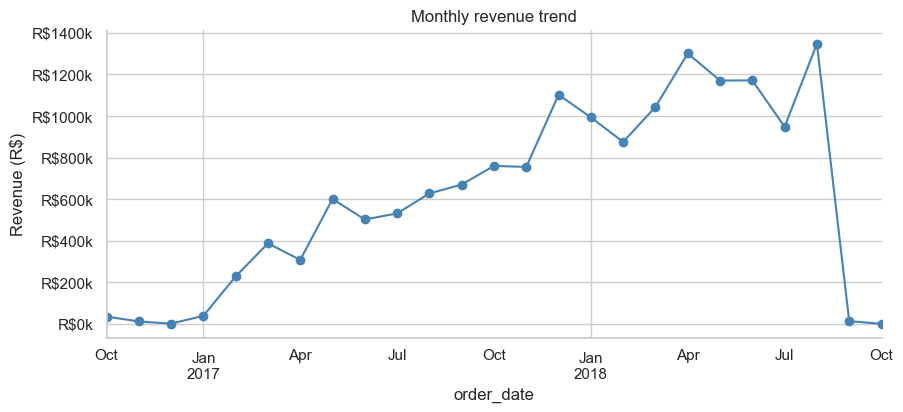

In [ ]:
query = """ 
    select
        odd.order_delivered_customer_date,  ocd.order_cost
    from orders_delivery_details odd
    LEFT JOIN order_cost_details ocd
    on odd.order_id = ocd.order_id
    where odd.order_delivered_customer_date is not null
    order by odd.order_delivered_customer_date desc
"""

df = conn.execute(query).df()
df['order_date'] = pd.to_datetime(
    df['order_delivered_customer_date'])

monthly = df.resample(
    'M', on='order_date')['order_cost'].sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_title('Monthly Revenue Trend', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (R$)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}k'))
monthly.plot(figsize=(10,4),
             marker='o',
             color='steelblue')
plt.title('Monthly revenue trend')

## Delayed order analysis

In [ ]:
# Let's see which orders were delayed

query = """
    select 
        vod.order_id, customer_id, days_till_approval, days_till_shipped, days_till_delivered, 
        days_till_estim_delivery, delivery_days_accuracy, total_products, 
        total_cost, total_freight_value, total_cost_customer,
        shipping_burden
    from view_orders_delivered vod
    LEFT JOIN
    order_cost_detils ocd
    on vod.order_id = ocd.order_id
    where delivery_days_accuracy   > 0
    order by delivery_days_accuracy   desc

"""
result = conn.execute(query).df().head()
print(result)

                           order_id                       customer_id  \
0  1b3190b2dfa9d789e1f14c05b647a14a  d306426abe5fca15e54b645e4462dc7b   
1  ca07593549f1816d26a572e06dc1eab6  75683a92331068e2d281b11a7866ba44   
2  47b40429ed8cce3aee9199792275433f  cb2caaaead400c97350c37a3fc536867   
3  2fe324febf907e3ea3f2aa9650869fa5  65b14237885b3972ebec28c0f7dd2220   
4  285ab9426d6982034523a855f55a885e  9cf2c3fa2632cee748e1a59ca9d09b21   

   days_till_approval  days_till_shipped  days_till_delivered  \
0                   0                  3                  208   
1                   2                 15                  210   
2                   0                 34                  191   
3                   0                  4                  190   
4                   0                  1                  195   

   days_till_estim_delivery  delivery_days_accuracy  total_products  \
0                        20                     188               1   
1                        29 

In [5]:
# holistic view of orders delivered across cities and states

query = """
    select 
        odd.order_id, odd.days_till_delivery as delivery_days, c.customer_city as city, c.customer_state as state
    from view_orders_delivered odd
    LEFT JOIN customers c
    on odd.customer_id = c.customer_id
    

"""
# average delivery time across states
query = """ 
    SELECT 
        c.customer_state as state, c.customer_city as city,
        count(odd.order_id) as total_orders,
        round(AVG(odd.days_till_delivered),2) as avg_delivery_time,
        round(avg((delivery_days_accuracy)),2) as avg_delivery_accuracy,
        round(sum(ocd.order_cost),2) as total_revenue_generated,
        round(avg(ocd.shipping_burden),2) as avg_shipping_burden
    FROM view_orders_delivered odd
    JOIN customers c ON odd.customer_id = c.customer_id
    LEFT JOIN order_cost_details as ocd
    on odd.order_id = ocd.order_id
    group by state, city
    order by total_orders desc
"""
result = conn.execute(query).df().head()
print("Average delivery time across states - \n ", result)

Average delivery time across states - 
    state            city  total_orders  avg_delivery_time  \
0    SP       sao paulo         15119               8.00   
1    RJ  rio de janeiro          6614              14.67   
2    MG  belo horizonte          2701              11.02   
3    DF        brasilia          2076              12.88   
4    PR        curitiba          1496              10.37   

   avg_delivery_accuracy  total_revenue_generated  avg_shipping_burden  
0                 -10.74               2107960.17                16.73  
1                 -13.23               1111732.21                23.98  
2                 -12.63                405950.51                22.57  
3                 -12.06                345199.05                24.17  
4                 -13.49                238459.72                22.07  


In [9]:
# % of orders delivered late vs on time
query = """ 
    with on_time_orders as(
        SELECT 
            order_id, delivery_days_accuracy, 
        FROM view_orders_delivered
        where delivery_days_accuracy <= 0
    ),
    delayed_orders as (
        SELECT 
            order_id, delivery_days_accuracy
        FROM view_orders_delivered
        where delivery_days_accuracy > 0
    )
    select 
        count(ot.order_id) as total_ontime, 
        count(dor.order_id) as total_delayed,
        (total_ontime)/(total_ontime + total_delayed) as per_on_time,
        (total_delayed)/(total_ontime + total_delayed) as per_delayed,
    from on_time_orders as ot
    FULL OUTER JOIN delayed_orders as dor
    on ot.order_id = dor.order_id

"""
result = conn.execute(query).df().head()
print("% of orders delivered late vs on time - \n ", result)

% of orders delivered late vs on time - 
     total_ontime  total_delayed  per_on_time  per_delayed
0         89936           6534     0.932269     0.067731


Therefore, the shipping limit breach is 0.06% that is 6,534 orders were delivered after the expected delivery time.

In [7]:
query = """ 
    select * from information_schema.tables
"""

conn.execute(query).df()

,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action,TABLE_COMMENT
0,olist,main,customers,BASE TABLE,None,None,None,None,None,YES,NO,None,None
1,olist,main,geoloc,BASE TABLE,None,None,None,None,None,YES,NO,None,None
2,olist,main,orders,BASE TABLE,None,None,None,None,None,YES,NO,None,None
3,olist,main,orders_delivery_details,BASE TABLE,None,None,None,None,None,YES,NO,None,None
4,olist,main,order_cost_details,BASE TABLE,None,None,None,None,None,YES,NO,None,None
5,olist,main,order_cost_detils,BASE TABLE,None,None,None,None,None,YES,NO,None,None
6,olist,main,order_items,BASE TABLE,None,None,None,None,None,YES,NO,None,None
7,olist,main,order_payments,BASE TABLE,None,None,None,None,None,YES,NO,None,None
8,olist,main,order_payments_agg,BASE TABLE,None,None,None,None,None,YES,NO,None,None
9,olist,main,order_reviews,BASE TABLE,None,None,None,None,None,YES,NO,None,None


# Seller performance

In [19]:
query = """ 
    select 
        *
    from seller_performance
"""
conn.execute(query).df().head()

,seller_id,product_id,order_id,orders_total,across_products,price_value,freight_value,cost_total,shipping_burden
0,92eb0f42c21942b6552362b9b114707d,23365beed316535b4105bd800c46670e,0014ae671de39511f7575066200733b7,1,1,16.50,14.10,30.60,14.9545
1,955fee9216a65b617aa5c0531780ce60,35537536ed2b4c561b4018bf3abf54e0,0025c5d1a8ca53a240ec2634bb4492ea,1,1,390.00,29.39,419.39,29.4654
2,7c67e1448b00f6e969d365cea6b010ab,4c1bbc12438daec98a77243c2bf7a3ba,0036757472ece3dde52fd4bfd929c90e,1,1,136.99,66.04,203.03,66.5221
3,f80edd2c5aaa505cc4b0a3b219abf4b8,452f66a0f164cac57802e2cea93188ac,003a94f778ef8cfd50247c8c1b582257,1,1,39.90,18.08,57.98,18.5331
4,7210cd29727d674c00741e5e387b3ccd,0c4a0f8ab44f9acd2d04e7024f9ba362,00526a9d4ebde463baee25f386963ddc,1,1,135.56,33.60,169.16,34.5914


In [11]:
query = """ 
    select 
        seller_id, count(order_id) as total_orders
    from seller_performance
    group by seller_id
"""
conn.execute(query).df().head()

,seller_id,total_orders
0,f80edd2c5aaa505cc4b0a3b219abf4b8,120
1,c4fb51fb1c5b7c07bc5e67be6e7e8f6e,15
2,9f505651f4a6abe901a56cdc21508025,398
3,ef30892870c278497523264be1be2241,9
4,e62b2d6ac10570a035a30bafcf01d263,63


In [17]:
query = """ 
    with agg_sellerp as(
        select 
            seller_id, count(order_id) as total_orders
        from seller_performance
        group by seller_id
    )
    select round(avg(total_orders),2), median(total_orders), mode(total_orders) from agg_sellerp
"""
conn.execute(query).df().head()

,"round(avg(total_orders), 2)",median(total_orders),"""mode""(total_orders)"
0,33.09,7.0,1


The total orders per seller is concentrated more towards right as mean > median.

### Working with the pareto principle
Is this data concentrated? Is 80% of orders provided by 20% of sellers?

In [ ]:
query = """ 
    select * from seller_aggregated
"""

conn.execute(query).df()

,seller_id,total_orders,total_cost,pct_orders,cumulative_pct
0,6560211a19b47992c3666cc44a7e94c0,1982,151265.77,2.0,1.94
1,4a3ca9315b744ce9f8e9374361493884,1889,235539.96,2.0,3.78
2,cc419e0650a3c5ba77189a1882b7556a,1720,129957.41,2.0,5.46
3,1f50f920176fa81dab994f9023523100,1473,142104.98,1.0,6.90
4,da8622b14eb17ae2831f4ac5b9dab84a,1438,185192.32,1.0,8.30
...,...,...,...,...,...
3090,57a834594e1e9e9219603bfec184eadc,1,166.05,0.0,100.00
3091,9ac75591b69c3402684b6ce0310f22ee,1,69.67,0.0,100.00
3092,578460d8319c51dab351cd9db95eadfe,1,270.45,0.0,100.00
3093,4450bd8327d471c4a11a83d1445b1b62,1,214.56,0.0,100.00


In [ ]:
query = """ 

    select count(seller_id) from seller_aggregated
    where cumulative_pct < =50
"""
conn.execute(query).df()

,count(seller_id)
0,128


So from 3,095 sellers 128 of them contribute towards 50% of ours orders. Which is bit concerning and confirms that the order levels are concentrated for these sellers.

In [ ]:
query = """ 
    create or replace view seller_concentrated as
    select * from seller_aggregated
    where cumulative_pct <=80
"""
conn.execute(query)

In [ ]:
query = """ 
    create or replace view seller_concentrated_reviews as
    with seller_concentrated as (
        select * from seller_aggregated
        where cumulative_pct <=80
    ),
    seller_reviews as (
        select 
            seller_id, sc.order_id,orders_total, cost_total, shipping_burden,
            review_score, 
        from seller_performance sc
        LEFT JOIN order_reviews ord
        on sc.order_id = ord.order_id
    )
    select
        sc.seller_id, sc.total_orders, round((sc.total_cost),2) as total_cost, sc.pct_orders, sc.cumulative_pct,
        round(avg(sr.review_score),2)  as avg_score
    from seller_concentrated sc
    LEFT JOIN seller_reviews sr
    on sc.seller_id = sr.seller_id
    group by sc.seller_id, sc.total_orders, sc.total_cost, sc.pct_orders, sc.cumulative_pct,
"""
conn.execute(query)

In [80]:
query = """ 
    
    select
        *
    from seller_concentrated_reviews
    order by total_orders desc LIMIT 10
"""
conn.execute(query).df()

,seller_id,total_orders,total_cost,pct_orders,cumulative_pct,avg_score
0,6560211a19b47992c3666cc44a7e94c0,1982,151265.77,2.0,1.94,3.92
1,4a3ca9315b744ce9f8e9374361493884,1889,235539.96,2.0,3.78,3.82
2,cc419e0650a3c5ba77189a1882b7556a,1720,129957.41,2.0,5.46,4.07
3,1f50f920176fa81dab994f9023523100,1473,142104.98,1.0,6.90,4.11
4,da8622b14eb17ae2831f4ac5b9dab84a,1438,185192.32,1.0,8.30,4.10
5,955fee9216a65b617aa5c0531780ce60,1290,160602.68,1.0,9.56,4.16
6,ea8482cd71df3c1969d7b9473ff13abc,1169,54722.29,1.0,10.70,3.97
7,7a67c85e85bb2ce8582c35f2203ad736,1166,162648.38,1.0,11.84,4.24
8,4869f7a5dfa277a7dca6462dcf3b52b2,1143,249640.70,1.0,12.96,4.13
9,3d871de0142ce09b7081e2b9d1733cb1,1125,117347.71,1.0,14.05,4.13


Since, 531 out of 3095 which makes almost 17% of sellers that contribute towards 80% of our orders. Which means, if top 5-10 sellers stopped contributing and left, upto 10-15% of our sales will be gone with them.

In [86]:
# Analysing the review scenario for these sellers.
query = """ 
    
    select
        round(avg(avg_score),2), median(avg_score), max(avg_score), min(avg_score)
    from seller_concentrated_reviews
"""
conn.execute(query).df()

,"round(avg(avg_score), 2)",median(avg_score),max(avg_score),min(avg_score)
0,4.1,4.15,4.82,2.31


In [90]:
# % of sellers with less than the avg review score of 3.5
query = """ 
    with total_sellers as (
        select sum(total_orders) as total_orders
        from seller_concentrated_reviews
    ),
    sellers_3_5_less as (
        select sum(total_orders) as seller_low_score_orders
        from seller_concentrated_reviews
        where avg_score <=3.5
    )
    select
        seller_low_score_orders*100/total_orders
    from total_sellers, sellers_3_5_less
    
"""
conn.execute(query).df()

,((seller_low_score_orders * 100) / total_orders)
0,3.849441


Almost 4% of orders make up the sellers with avg reviews less than 3.5

### Exploring other 20% of sellers

In [149]:
query = """ 
    create or replace view other_seller_reviews as
    with other_sellers as (
        select
            *
        from pareto_principle 
        where cumulative_pct > 80
    ),
    total_orders as (
        select sum(orders_total) as total_ord from seller_performance
    ),
    total_orders_other as (
        select sum(total_orders) as total_ordo from other_sellers
    ),
    get_reviews as (
        select
            sp.seller_id, 
            count(product_id) as total_products, 
            round(sum(price_value),2) as price_value, 
            round(sum(freight_value),2) as freight_value,
            count(review_id) as review_count,
            round(avg(review_score),2) as avg_review_score
        from seller_performance sp
        LEFT JOIN order_reviews ordr
        on sp.order_id = ordr.order_id
        group by sp.seller_id
    ),
    other_reviews as (
        select 
            *            
        from other_sellers osr
        LEFT JOIN get_reviews gr
        on osr.seller_id = gr.seller_id
        
    )
    select 
        seller_id, total_orders, round(total_cost,2) as total_cost, cumulative_pct, 
        total_products, price_value, freight_value, review_count, avg_review_score as avg_rscore
    from other_reviews
    
"""

conn.execute(query)

In [150]:
conn.execute("""select * from other_seller_reviews""").df()

,seller_id,total_orders,total_cost,cumulative_pct,total_products,price_value,freight_value,review_count,avg_rscore
0,9853a239ab7b7ebbdc3a21248d5b8e1f,5,471.01,97.51,5,381.00,90.01,5,3.80
1,6426d21aca402a131fc0a5d0960a3c90,23,1593.82,86.56,23,1209.64,384.18,23,4.17
2,2e3be8a987a30d7544dbbda6861cc14e,18,4777.55,89.13,18,4430.84,346.71,18,3.17
3,b1b3948701c5c72445495bd161b83a4c,18,25185.49,89.13,18,24699.19,486.30,18,1.72
4,fde0cc9ea29c8ccfc0a2c22256a58c71,35,4921.27,81.53,35,3922.00,999.27,35,4.49
...,...,...,...,...,...,...,...,...,...
2559,2cb98e27ce1c18abdb42209b34c382a7,1,119.70,100.00,1,62.49,57.21,1,4.00
2560,3e35a8bb43569389d3cebef0ce820f69,1,84.68,100.00,1,55.80,28.88,1,5.00
2561,1746c1ae87ac63d530c7c943d0ac42e2,1,252.35,100.00,1,229.90,22.45,1,5.00
2562,3820c6537b3853be1a0687d5a60807ec,1,35.96,100.00,1,25.00,10.96,0,NaN


In [151]:
# Avg review for these sellers
conn.execute("""select avg(avg_rscore), median(avg_rscore), min(avg_rscore), max(avg_rscore) from other_seller_reviews""").df()

,avg(avg_rscore),median(avg_rscore),min(avg_rscore),max(avg_rscore)
0,3.973283,4.21,1.0,5.0


In [171]:
conn.execute("""
             select  
                case
                    when (avg_rscore >= 0 and avg_rscore < 3) then 'Poor'
                    when (avg_rscore >=3 and avg_rscore < 3.75) then 'Not bad'
                    when (avg_rscore >=3.75 and avg_rscore < 4.5) then 'Good'
                    when  (avg_rscore >=4.5 and avg_rscore <=5) then 'Best'
                    else 'NA'
                end as rating,
                count(seller_id) as seller_count,
                sum(total_orders) as order_count
             from other_seller_reviews 
             group by rating
             order by seller_count desc""").df()

,rating,seller_count,order_count
0,Best,941,4821.0
1,Good,927,11766.0
2,Not bad,387,2989.0
3,Poor,304,936.0
4,NA,5,5.0


In [172]:
conn.close()